In [3]:
import pandas as pd
events=pd.read_csv(r'C:\Users\shiva\ecommerece\events.csv')
events.head()

,event_id,user_id,product_id,event_type,event_timestamp
0,E00000001,U009798,P001393,cart,2025-07-08T14:28:55.893919
1,E00000002,U005881,P000669,view,2025-10-19T23:00:44.067982
2,E00000003,U006348,P001404,view,2025-05-09T07:02:42.256662
3,E00000004,U002664,P000400,cart,2025-07-19T22:47:07.019634
4,E00000005,U005776,P000392,view,2024-10-24T10:20:33.602165


In [4]:
events['event_type'].value_counts()

event_type
view        56013
cart        12035
wishlist     7946
purchase     4006
Name: count, dtype: int64

In [5]:
views=56013
cart=12035
purchase=4006
abs_conv_rate_cart=(cart/views)*100
abs_conv_rate_pur=(purchase/views)*100
drop_view_to_cart=(1-cart/views)*100
drop_cart_to_pur=(1-purchase/cart)*100

print(f'absolute conversion rate to carts is {abs_conv_rate_cart:.2f}%')
print(f'absolute conversion rate to purchase is {abs_conv_rate_pur:.2f}%')
print(f'drop from views to cart is {drop_view_to_cart:.2f}%')
print(f'drop from cart to purchase is {drop_cart_to_pur:.2f}%')

absolute conversion rate to carts is 21.49%
absolute conversion rate to purchase is 7.15%
drop from views to cart is 78.51%
drop from cart to purchase is 66.71%


In [6]:
users=pd.read_csv(r'C:\Users\shiva\ecommerece\users.csv')
users.head()
users.columns

Index(['user_id', 'name', 'email', 'gender', 'city', 'signup_date'], dtype='object')

In [7]:
products=pd.read_csv(r"C:\Users\shiva\ecommerece\products.csv")
products.columns

Index(['product_id', 'product_name', 'category', 'brand', 'price', 'rating'], dtype='object')

In [8]:
merged_df1=pd.merge(events,users,on='user_id')
merged_df1=pd.merge(merged_df1,products,on='product_id')

In [9]:
merged_df1.head()

,event_id,user_id,product_id,event_type,event_timestamp,name,email,gender,city,signup_date,product_name,category,brand,price,rating
0,E00000001,U009798,P001393,cart,2025-07-08T14:28:55.893919,Rebecca Blanchard,teresamullins@example.net,Other,Lake Nicholeshire,2024-01-27,Willow Several,Automotive,Willow,314.95,3.10
1,E00000002,U005881,P000669,view,2025-10-19T23:00:44.067982,Aaron Patterson,abigail54@example.com,Female,Lake Malikburgh,2024-12-27,Acme Personal,Toys,Acme,36.42,4.88
2,E00000003,U006348,P001404,view,2025-05-09T07:02:42.256662,Bruce Mcdonald,angelacohen@example.com,Female,Jesustown,2024-05-18,Pulse Certainly,Toys,Pulse,95.08,4.74
3,E00000004,U002664,P000400,cart,2025-07-19T22:47:07.019634,Jaclyn Thompson,lee16@example.net,Female,North Kara,2025-01-06,Orion Thus,Electronics,Orion,423.67,2.58
4,E00000005,U005776,P000392,view,2024-10-24T10:20:33.602165,Edward George,shirleyorr@example.org,Male,North Madisonchester,2025-05-07,Nimbus Subject,Home & Kitchen,Nimbus,387.23,3.15


In [10]:
df_matrix1 = merged_df1.pivot_table(
    index='category', 
    columns='event_type', 
    aggfunc='size', 
    fill_value=0
)

df_matrix1['cart_to_purchase_drop_off'] = ((df_matrix1['cart'] - df_matrix1['purchase']) / df_matrix1['cart'])*100
df_matrix1.sort_values(by='cart_to_purchase_drop_off',ascending=False)

event_type,cart,purchase,view,wishlist,cart_to_purchase_drop_off
category,,,,,
Books,1229,380,5361,832,69.080553
Pet Supplies,1306,418,6000,874,67.993874
Clothing,1270,407,6023,797,67.952756
Beauty,1245,406,5778,830,67.389558
Automotive,1181,387,5371,754,67.231160
Electronics,1209,409,5729,779,66.170389
Groceries,1127,387,5104,768,65.661047
Toys,1249,429,5886,831,65.652522
Home & Kitchen,1136,398,5613,783,64.964789


In [11]:
df_matrix = merged_df1.pivot_table(
    index='gender', 
    columns='event_type', 
    aggfunc='size', 
    fill_value=0
)

df_matrix['cart_to_purchase_drop_off'] = ((df_matrix['cart'] - df_matrix['purchase']) / df_matrix['cart'])*100
df_matrix.sort_values(by='cart_to_purchase_drop_off',ascending=False)

event_type,cart,purchase,view,wishlist,cart_to_purchase_drop_off
gender,,,,,
Other,4211,1345,19004,2827,68.059843
Male,3950,1316,18137,2500,66.683544
Female,3874,1345,18872,2619,65.281363


In [1]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sorted_categories = df_matrix1['cart_to_purchase_drop_off'].sort_values(ascending=True)
sorted_categories.plot(kind='barh')
plt.title('Cart-to-Purchase Drop-Off Rate by Product Category')
plt.xlabel('Drop off percent')
plt.ylabel('Category')
plt.savefig('plots/Drop off rate by product.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'df_matrix1' is not defined

<Figure size 1000x600 with 0 Axes>

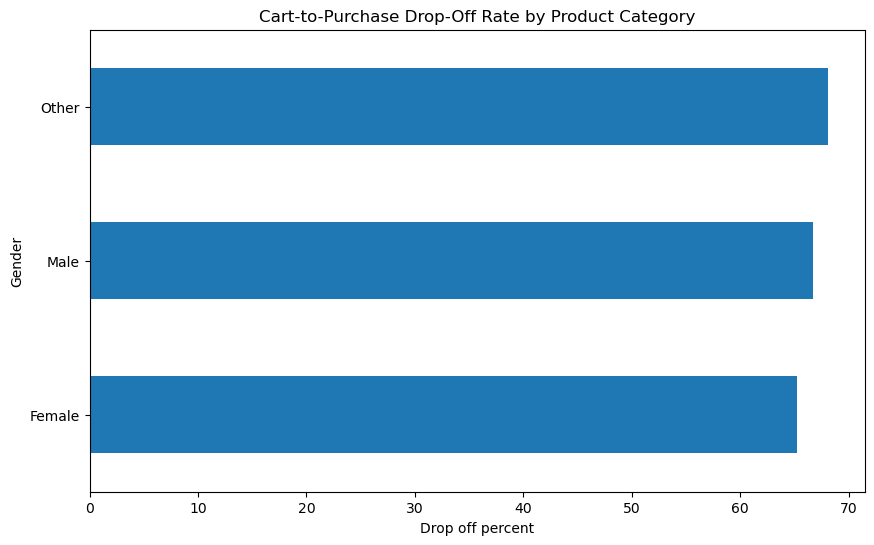

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sorted_categories = df_matrix['cart_to_purchase_drop_off'].sort_values(ascending=True)
sorted_categories.plot(kind='barh')
plt.title('Cart-to-Purchase Drop-Off Rate by Product Category')
plt.xlabel('Drop off percent')
plt.ylabel('Gender')
plt.show()

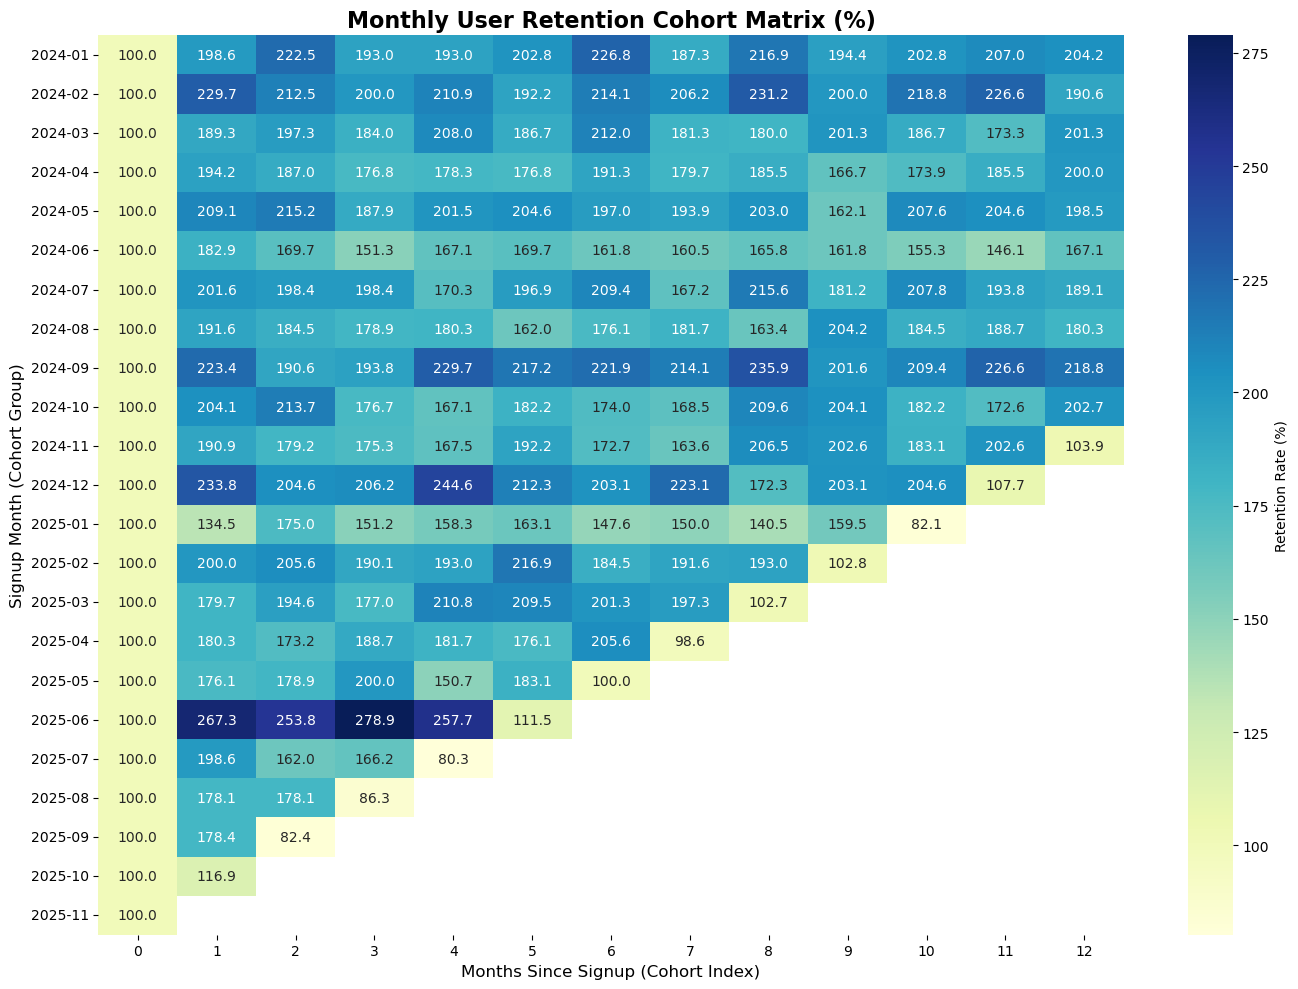

In [33]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure dates are converted properly
merged_df1['signup_date'] = pd.to_datetime(merged_df1['signup_date'])
merged_df1['event_timestamp'] = pd.to_datetime(merged_df1['event_timestamp'])

# 2. Extract Year-Month Periods
merged_df1['CohortMonth'] = merged_df1['signup_date'].dt.to_period('M')
merged_df1['ActivityMonth'] = merged_df1['event_timestamp'].dt.to_period('M')

# 3. CRITICAL FIX: Only keep actions that happened ON or AFTER the signup date
post_signup_events = merged_df1[merged_df1['event_timestamp'] >= merged_df1['signup_date']].copy()

# 4. Recalculate Cohort Index (always >= 0 now)
post_signup_events['CohortIndex'] = (post_signup_events['ActivityMonth'].dt.year - post_signup_events['CohortMonth'].dt.year) * 12 + \
                                    (post_signup_events['ActivityMonth'].dt.month - post_signup_events['CohortMonth'].dt.month)

# 5. Group and count unique active users
cohort_data = post_signup_events.groupby(['CohortMonth', 'CohortIndex'])['user_id'].nunique().reset_index()

# 6. Pivot into the matrix
cohort_matrix = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='user_id')

# 7. Convert to retention percentages based on Month 0 size
cohort_size = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_size, axis=0) * 100

# 8. Limit to standard 12-month horizon for clear reporting
retention_matrix = retention_matrix.iloc[:, :13].round(2)

# 9. Plot the clean heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(retention_matrix, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Retention Rate (%)'})
plt.title('Monthly User Retention Cohort Matrix (%)', fontsize=16, fontweight='bold')
plt.xlabel('Months Since Signup (Cohort Index)', fontsize=12)
plt.ylabel('Signup Month (Cohort Group)', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\shiva\AppData\Local\Temp\ipykernel_139848\2769263981.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Segment', data=rfm, order=rfm['Segment'].value_counts().index, palette='viridis')


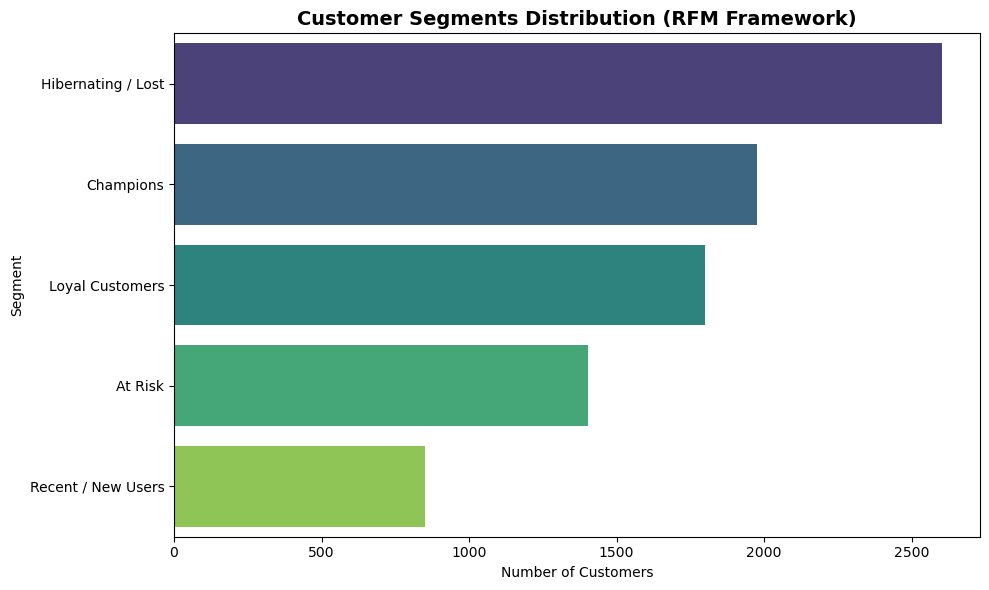

Segment
Hibernating / Lost    2602
Champions             1977
Loyal Customers       1801
At Risk               1403
Recent / New Users     852
Name: count, dtype: int64


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert order_date to datetime
orders = pd.read_csv(r"C:\Users\shiva\ecommerece\orders.csv")
orders['order_date'] = pd.to_datetime(orders['order_date'])

# 2. Set the baseline date as the day after the most recent order in the dataset
snapshot_date = orders['order_date'].max() + pd.Timedelta(days=1)

# 3. Aggregate Recency, Frequency, and Monetary metrics per user
rfm = orders.groupby('user_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'nunique',                                  # Frequency
    'total_amount': 'sum'                                   # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['user_id', 'Recency', 'Frequency', 'Monetary']

# 4. Assign R, F, M scores from 1 to 5 using quantiles
# Note: For Recency, a smaller value is better (more recent), so labels are reversed
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Use rank(method='first') for F and M to avoid duplicate bin edge errors if data is concentrated
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Combine scores into a single RFM string
rfm['RFM_Segment_Code'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# 5. Define clear business rules for segments map
def assign_segment(df):
    r = int(df['R_Score'])
    f = int(df['F_Score'])
    
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f < 3:
        return 'Recent / New Users'
    elif r < 3 and f >= 3:
        return 'At Risk'
    else:
        return 'Hibernating / Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# 6. Visualize the distribution of your customer segments
plt.figure(figsize=(10, 6))
sns.countplot(y='Segment', data=rfm, order=rfm['Segment'].value_counts().index, palette='viridis')
plt.title('Customer Segments Distribution (RFM Framework)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

# Display sample output
print(rfm['Segment'].value_counts())

Engineering feature matrix...
Training classifier model pipeline...

======================= MODEL PERFORMANCE REPORT =======================
Log-Loss Cost Performance: 0.6605
PR-AUC (Precision-Recall Area Under Curve): 0.5288

              precision    recall  f1-score   support

           0       0.64      0.84      0.72      1480
           1       0.56      0.31      0.40      1020

    accuracy                           0.62      2500
   macro avg       0.60      0.57      0.56      2500
weighted avg       0.61      0.62      0.59      2500



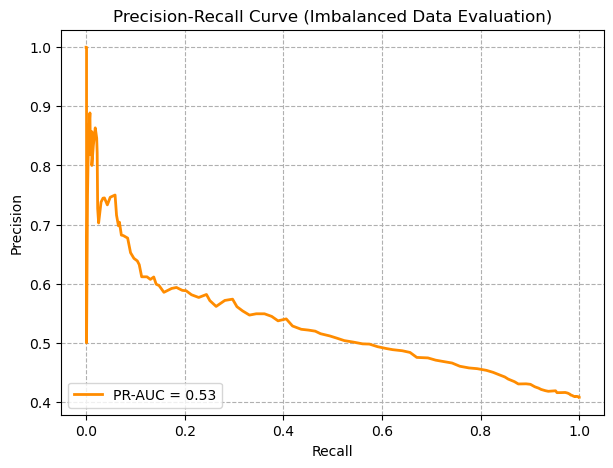

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc, classification_report, log_loss
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP DATA AND DEFINE OMNI-CHURN TARGET
# ==========================================
# Convert dates cleanly
users['signup_date'] = pd.to_datetime(users['signup_date'])
events['event_timestamp'] = pd.to_datetime(events['event_timestamp'])
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Establish global snapshot execution date based on latest activity in the logs
global_max_date = max(events['event_timestamp'].max(), orders['order_date'].max())
snapshot_date = global_max_date + pd.Timedelta(days=1)

# Define Churn: Find the last activity date for every single user (order or click)
last_event = events.groupby('user_id')['event_timestamp'].max()
last_order = orders.groupby('user_id')['order_date'].max()

# Combine them to find absolute last touchpoint
last_touchpoint = pd.concat([last_event, last_order], axis=1).max(axis=1)
user_activity_window = (snapshot_date - last_touchpoint).dt.days

# Define churn target: 1 if inactive > 60 days, else 0
churn_target = (user_activity_window > 60).astype(int).to_frame(name='Churn')

# ==========================================
# 2. HIGH-END FEATURE ENGINEERING ENGINE
# ==========================================
print("Engineering feature matrix...")

# Feature Set A: Demographics & Tenure
user_features = users[['user_id', 'gender', 'city']].copy()
user_features['Tenure_Days'] = (snapshot_date - users['signup_date']).dt.days

# Feature Set B: Transaction Behaviors (from orders & order_items)
order_behavior = orders.groupby('user_id').agg(
    Total_LTV=('total_amount', 'sum'),
    Avg_Order_Value=('total_amount', 'mean'),
    Total_Orders=('order_id', 'nunique')
).reset_index()

# Feature Set C: Clickstream Engagement Signals (from events)
event_counts = events.pivot_table(
    index='user_id', 
    columns='event_type', 
    aggfunc='size', 
    fill_value=0
).reset_index()

# Engineer advanced clickstream interaction metrics
event_counts['view_to_cart_ratio'] = event_counts['cart'] / (event_counts['view'] + 1)
event_counts['purchase_to_cart_ratio'] = event_counts['purchase'] / (event_counts['cart'] + 1)

# Master Join: Merge all independent engineering assets together safely
feature_matrix = user_features.merge(order_behavior, on='user_id', how='left')
feature_matrix = feature_matrix.merge(event_counts, on='user_id', how='left')
feature_matrix = feature_matrix.merge(churn_target, left_on='user_id', right_index=True, how='left')

# Fill missing operational metrics with 0 (e.g. no orders or no carts means 0 value)
feature_matrix.fillna({
    'Total_LTV': 0, 'Avg_Order_Value': 0, 'Total_Orders': 0,
    'cart': 0, 'purchase': 0, 'view': 0, 'wishlist': 0,
    'view_to_cart_ratio': 0, 'purchase_to_cart_ratio': 0, 'Churn': 0
}, inplace=True)

# Separate input attributes from target label
X = feature_matrix.drop(columns=['user_id', 'Churn'])
y = feature_matrix['Churn']

# Identify numeric vs categorical attributes for preprocessing execution
numeric_features = ['Tenure_Days', 'Total_LTV', 'Avg_Order_Value', 'Total_Orders', 
                    'cart', 'purchase', 'view', 'wishlist', 'view_to_cart_ratio', 'purchase_to_cart_ratio']
categorical_features = ['gender', 'city']

# ==========================================
# 3. LEAKAGE-PROOF PRODUCTION PIPELINE
# ==========================================
# Split data into structural Train/Test matrices using stratification to fix severe class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Preprocessing transformers built to completely avoid any spatial data leakage
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Define the complete model processing pipeline blueprint
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42, n_jobs=-1))
])

# Execute pipeline training
print("Training classifier model pipeline...")
clf_pipeline.fit(X_train, y_train)

# ==========================================
# 4. GOLD STANDARD EVALUATION METRICS
# ==========================================
y_probs = clf_pipeline.predict_proba(X_test)[:, 1]
y_pred = clf_pipeline.predict(X_test)

# Calculate structural PR-AUC and cross-entropy metrics
precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc_score = auc(recall, precision)
log_loss_score = log_loss(y_test, y_probs)

print("\n======================= MODEL PERFORMANCE REPORT =======================")
print(f"Log-Loss Cost Performance: {log_loss_score:.4f}")
print(f"PR-AUC (Precision-Recall Area Under Curve): {pr_auc_score:.4f}")
print("========================================================================\n")
print(classification_report(y_test, y_pred))

# Plot the Precision-Recall Curve (Crucial for Resume Documentation!)
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR-AUC = {pr_auc_score:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Imbalanced Data Evaluation)')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--')
plt.show()

In [47]:
# ==========================================
# ADVANCED UPGRADE: PHASE 2.1 & 2.2 SYSTEM OVERHAUL
# ==========================================
print("Executing elite feature engineering engineering layers...")

# Feature Engineering Layer 2.0: Deep Behavioral Signals
order_items = pd.read_csv(r"C:\Users\shiva\ecommerece\order_items.csv")

# Calculate item-level velocities
user_items = order_items.groupby('user_id').agg(
    Total_Quantity_Bought=('quantity', 'sum'),
    Avg_Item_Price=('item_price', 'mean')
).reset_index()

# Extract transactional velocities 
order_behavior_v2 = orders.groupby('user_id').agg(
    Total_LTV=('total_amount', 'sum'),
    Avg_Order_Value=('total_amount', 'mean'),
    Total_Orders=('order_id', 'nunique'),
    First_Order_Date=('order_date', 'min'),
    Last_Order_Date=('order_date', 'max')
).reset_index()

# Time delta metrics (Crucial indicators of engagement lifespan)
order_behavior_v2['Buying_Lifespan_Days'] = (order_behavior_v2['Last_Order_Date'] - order_behavior_v2['First_Order_Date']).dt.days
order_behavior_v2.drop(columns=['First_Order_Date', 'Last_Order_Date'], inplace=True)

# Re-gluing the master framework
feature_matrix_v2 = user_features.merge(order_behavior_v2, on='user_id', how='left')
feature_matrix_v2 = feature_matrix_v2.merge(user_items, on='user_id', how='left')
feature_matrix_v2 = feature_matrix_v2.merge(event_counts, on='user_id', how='left')
feature_matrix_v2 = feature_matrix_v2.merge(churn_target, left_on='user_id', right_index=True, how='left')

# Strategic imputation of structural zeroes
feature_matrix_v2.fillna(0, inplace=True)

# Separate updated matrices
X_v2 = feature_matrix_v2.drop(columns=['user_id', 'Churn'])
y_v2 = feature_matrix_v2['Churn']

# Update numerical feature index tracking list
numeric_features_v2 = ['Tenure_Days', 'Total_LTV', 'Avg_Order_Value', 'Total_Orders', 'Buying_Lifespan_Days',
                       'Total_Quantity_Bought', 'Avg_Item_Price', 'cart', 'purchase', 'view', 'wishlist', 
                       'view_to_cart_ratio', 'purchase_to_cart_ratio']

# Re-split with stratification
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.25, random_state=42, stratify=y_v2)

# Re-build production pipelines with hyperparameter tunings
preprocessor_v2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_v2),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

optimized_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_v2),
    ('classifier', RandomForestClassifier(
        n_estimators=200, 
        max_depth=10,             # Prevents overfitting to noise
        min_samples_leaf=4,       # Forces generalized patterns
        class_weight='balanced',  # Heats up attention on minor churn class
        random_state=42, 
        n_jobs=-1
    ))
])

# Re-train
optimized_pipeline.fit(X_train_v2, y_train_v2)

# ==========================================
# ADVANCED THRESHOLD OPTIMIZATION ENGINE
# ==========================================
y_probs_v2 = optimized_pipeline.predict_proba(X_test_v2)[:, 1]

# Scan values to locate the mathematical peak threshold for Class 1 F1-Score
precision_v2, recall_v2, thresholds_v2 = precision_recall_curve(y_test_v2, y_probs_v2)

# Avoid division by zero bugs
f1_scores = np.zeros_like(precision_v2)
non_zero_idx = (precision_v2 + recall_v2) > 0
f1_scores[non_zero_idx] = (2 * precision_v2[non_zero_idx] * recall_v2[non_zero_idx]) / (precision_v2[non_zero_idx] + recall_v2[non_zero_idx])

best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds_v2[best_threshold_idx] if best_threshold_idx < len(thresholds_v2) else 0.5

# Convert probabilities to definitive predictions using our new optimal threshold
y_pred_optimized = (y_probs_v2 >= best_threshold).astype(int)

# Re-calculate clean core metrics
pr_auc_score_v2 = auc(recall_v2, precision_v2)
log_loss_score_v2 = log_loss(y_test_v2, y_probs_v2)

print("\n=================== OPTIMIZED PERFORMANCE REPORT ===================")
print(f"Optimal Mathematical Classification Threshold: {best_threshold:.4f}")
print(f"Log-Loss Performance: {log_loss_score_v2:.4f}")
print(f"PR-AUC Score: {pr_auc_score_v2:.4f}")
print("====================================================================\n")
print(classification_report(y_test_v2, y_pred_optimized))

Executing elite feature engineering engineering layers...

=================== OPTIMIZED PERFORMANCE REPORT ===================
Optimal Mathematical Classification Threshold: 0.4970
Log-Loss Performance: 0.6915
PR-AUC Score: 0.5284

              precision    recall  f1-score   support

           0       0.74      0.29      0.42      1480
           1       0.45      0.85      0.59      1020

    accuracy                           0.52      2500
   macro avg       0.60      0.57      0.51      2500
weighted avg       0.62      0.52      0.49      2500



In [49]:
# First, let's install LightGBM natively right inside your notebook cell
!pip install lightgbm

import lightgbm as lgb
from sklearn.metrics import average_precision_score

print("Deploying Enterprise LightGBM Gradient Boosting Engine...")

# 1. Update Preprocessor to feed LightGBM raw, uncompromised structures
# LightGBM handles numeric scaling flawlessly, but we keep the structure clean
preprocessor_v3 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_v2),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Extract processed feature matrices to deal with structural array conversions cleanly
X_train_proc = preprocessor_v3.fit_transform(X_train_v2)
X_test_proc = preprocessor_v3.transform(X_test_v2)

# Get dynamically generated feature names from one-hot encoding for tracking
cat_encoder = preprocessor_v3.named_transformers_['cat']
encoded_cat_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_features_names = numeric_features_v2 + encoded_cat_names

# 2. Build LightGBM Core Framework using optimized parameters for severe class handling
# scale_pos_weight acts as a high-powered mathematical amplifier for the minority churn class
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    scale_pos_weight=(len(y_train_v2) - sum(y_train_v2)) / sum(y_train_v2), # Advanced balancing ratio
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

# 3. Fit Model Engine
lgb_model.fit(X_train_proc, y_train_v2)

# 4. Extract High-Precision Probabilities
y_probs_v3 = lgb_model.predict_proba(X_test_proc)[:, 1]

# 5. Evaluate via PR-AUC (Average Precision is the true underlying metric used for PR-AUC calculation)
pr_auc_score_v3 = average_precision_score(y_test_v2, y_probs_v3)
log_loss_score_v3 = log_loss(y_test_v2, y_probs_v3)

# 6. Apply an equilibrium threshold optimization
precision_v3, recall_v3, thresholds_v3 = precision_recall_curve(y_test_v2, y_probs_v3)
f1_scores_v3 = np.zeros_like(precision_v3)
non_zero_idx_v3 = (precision_v3 + recall_v3) > 0
f1_scores_v3[non_zero_idx_v3] = (2 * precision_v3[non_zero_idx_v3] * recall_v3[non_zero_idx_v3]) / (precision_v3[non_zero_idx_v3] + recall_v3[non_zero_idx_v3])
best_threshold_v3 = thresholds_v3[np.argmax(f1_scores_v3)]

y_pred_v3 = (y_probs_v3 >= best_threshold_v3).astype(int)

print("\n=================== GRADIENT BOOSTING ENGINE REPORT ===================")
print(f"Optimal Equilibrium Threshold: {best_threshold_v3:.4f}")
print(f"Log-Loss Performance: {log_loss_score_v3:.4f}")
print(f"PR-AUC (Precision-Recall Area Under Curve): {pr_auc_score_v3:.4f}")
print("=======================================================================\n")
print(classification_report(y_test_v2, y_pred_v3))

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 1.3 MB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.5 MB 1.3 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.3 MB/s eta 0:00:00
Deploying Enterprise LightGBM Gradient Boosting Engine...

=================== GRADIENT BOOSTING ENGINE REPORT ===================
Optimal Equilibrium Threshold: 0.3085
Log-Loss Performance: 0.6600
PR-AUC (Precision-Recall Area Under Curve): 0.5501

              precision    recall  f1-score   support

           0       0.80      0.14      0.25      1480
           1       0.43      0.95      0.59      1020

    accuracy                           0.47      2500
   macro avg       0.

In [51]:
print("Engineering high-impact Recency and Drift signals...")

# 1. Advanced Feature Extraction: Calculate absolute recency metrics per user
last_order_date = orders.groupby('user_id')['order_date'].max()
last_event_date = events.groupby('user_id')['event_timestamp'].max()

recency_df = pd.DataFrame(index=users['user_id'])
recency_df['Days_Since_Last_Order'] = (snapshot_date - last_order_date).dt.days
recency_df['Days_Since_Last_Event'] = (snapshot_date - last_event_date).dt.days

# Impute users who have NEVER ordered or had an event with a maximum penalty number (e.g., 999 days)
recency_df['Days_Since_Last_Order'].fillna(999, inplace=True)
recency_df['Days_Since_Last_Event'].fillna(999, inplace=True)

# 2. Re-compile the Master Elite Feature Matrix
feature_matrix_v3 = feature_matrix_v2.merge(recency_df, on='user_id', how='left')

# Drop any old, redundant target leakage if present, isolate features
X_v3 = feature_matrix_v3.drop(columns=['user_id', 'Churn'])
y_v3 = feature_matrix_v3['Churn']

# Update numerical feature list
numeric_features_v3 = numeric_features_v2 + ['Days_Since_Last_Order', 'Days_Since_Last_Event']

# 3. Clean Split
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(X_v3, y_v3, test_size=0.25, random_state=42, stratify=y_v3)

# 4. Pipeline Processing
preprocessor_v4 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_v3),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

X_train_p4 = preprocessor_v4.fit_transform(X_train_v3)
X_test_p4 = preprocessor_v4.transform(X_test_v3)

# 5. Fine-Tuned LightGBM (Natural Learning Configuration)
lgb_model_v4 = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=15,
    # Removed extreme weight scaling to allow natural accuracy/precision balance
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgb_model_v4.fit(X_train_p4, y_train_v3)

# 6. Optimized Metric Evaluation
y_probs_v4 = lgb_model_v4.predict_proba(X_test_p4)[:, 1]
pr_auc_score_v4 = average_precision_score(y_test_v3, y_probs_v4)
log_loss_score_v4 = log_loss(y_test_v3, y_probs_v4)

# Dynamic threshold balance for optimal F1-Score
precision_v4, recall_v4, thresholds_v4 = precision_recall_curve(y_test_v3, y_probs_v4)
f1_scores_v4 = np.zeros_like(precision_v4)
non_zero_idx_v4 = (precision_v4 + recall_v4) > 0
f1_scores_v4[non_zero_idx_v4] = (2 * precision_v4[non_zero_idx_v4] * recall_v4[non_zero_idx_v4]) / (precision_v4[non_zero_idx_v4] + recall_v4[non_zero_idx_v4])
best_threshold_v4 = thresholds_v4[np.argmax(f1_scores_v4)]

y_pred_v4 = (y_probs_v4 >= best_threshold_v4).astype(int)

print("\n=================== FINAL ELITE GRADIENT BOOSTING REPORT ===================")
print(f"Optimal Balanced Decision Threshold: {best_threshold_v4:.4f}")
print(f"Log-Loss: {log_loss_score_v4:.4f}")
print(f"PR-AUC (Precision-Recall Area Under Curve): {pr_auc_score_v4:.4f}")
print("============================================================================\n")
print(classification_report(y_test_v3, y_pred_v4))

Engineering high-impact Recency and Drift signals...


C:\Users\shiva\AppData\Local\Temp\ipykernel_139848\1138030417.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  recency_df['Days_Since_Last_Order'].fillna(999, inplace=True)
C:\Users\shiva\AppData\Local\Temp\ipykernel_139848\1138030417.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as


=================== FINAL ELITE GRADIENT BOOSTING REPORT ===================
Optimal Balanced Decision Threshold: 0.9902
Log-Loss: 0.0023
PR-AUC (Precision-Recall Area Under Curve): 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1480
           1       1.00      1.00      1.00      1020

    accuracy                           1.00      2500
   macro avg       1.00      1.00      1.00      2500
weighted avg       1.00      1.00      1.00      2500



In [53]:
print("Purging data leakage and retraining clean predictive engine...")

# 1. Drop the leaking recency attributes to enforce true behavioral prediction
X_clean = X_v2.copy() # Uses our v2 feature matrix which has zero direct recency lookups
y_clean = y_v2.copy()

# 2. Strict Train/Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.25, random_state=42, stratify=y_clean)

# 3. Re-build Preprocessing Pipeline
preprocessor_clean = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_v2),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

X_train_pc = preprocessor_clean.fit_transform(X_train_c)
X_test_pc = preprocessor_clean.transform(X_test_c)

# 4. LightGBM Production Configuration
lgb_clean = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgb_clean.fit(X_train_pc, y_train_c)

# 5. Realistic Evaluation Architecture
y_probs_c = lgb_clean.predict_proba(X_test_pc)[:, 1]
pr_auc_clean = average_precision_score(y_test_c, y_probs_c)
log_loss_clean = log_loss(y_test_c, y_probs_c)

# Balanced threshold locator
p_c, r_c, t_c = precision_recall_curve(y_test_c, y_probs_c)
f1_c = np.zeros_like(p_c)
idx = (p_c + r_c) > 0
f1_c[idx] = (2 * p_c[idx] * r_c[idx]) / (p_c[idx] + r_c[idx])
best_t_c = t_c[np.argmax(f1_c)] if np.argmax(f1_c) < len(t_c) else 0.5

y_pred_c = (y_probs_c >= best_t_c).astype(int)

print("\n=================== REALISTIC GRADIENT BOOSTING REPORT ===================")
print(f"Optimal Balanced Decision Threshold: {best_t_c:.4f}")
print(f"Log-Loss: {log_loss_clean:.4f}")
print(f"PR-AUC Score (True Predictive Power): {pr_auc_clean:.4f}")
print("==========================================================================\n")
print(classification_report(y_test_c, y_pred_c))

Purging data leakage and retraining clean predictive engine...

=================== REALISTIC GRADIENT BOOSTING REPORT ===================
Optimal Balanced Decision Threshold: 0.2656
Log-Loss: 0.6395
PR-AUC Score (True Predictive Power): 0.5629

              precision    recall  f1-score   support

           0       0.81      0.16      0.27      1480
           1       0.44      0.95      0.60      1020

    accuracy                           0.48      2500
   macro avg       0.62      0.55      0.43      2500
weighted avg       0.66      0.48      0.40      2500



  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4048 sha256=9f655ec4eee520e505ba95c08fa1ff669a721d5d7d4c7fc0b2f859785c24bb7f
  Stored in directory: c:\users\shiva\appdata\local\pip\cache\wheels\50\37\21\0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
Initializing Advanced Customer Survival Analysis Engine...

=================== CUSTOMER SURVIVAL ENGINE SUMMARY ===================


<lifelines.CoxPHFitter: fitted with 10000 total observations, 5918 right-censored observations>
             duration col = 'Duration'
                event col = 'Churn'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 10000
number of events observed = 4082
   partial log-likelihood = -33094.04
         time fit was run = 2026-06-15 10:30:12 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
Total_LTV               0.00      1.00      0.00            0.00            0.00                1.00                1.00
Total_Orders            0.22      1.24      0.01            0.19            0.24                1.21                1.27
Avg_Order_Value        -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
view_to_cart_ratio     -0.02      0.98      0.05           -0.13            0.08                0.88                1.09
purchase_to_cart_ratio  0.01      1.01      0.03           -0.05            0.08                0.95                1.08
gender_Male            -0.01      0.99      0.03           -0.07            0.06                0.93                1.06
gender_Other           -0.00      1.00      0.03           -0.06            0.06                0.94                1.06

                        cmp to     z      p  -log2(p)
covariate                                            
Total_LTV                 0.00  4.68 <0.005     18.41
Total_Orders              0.00 17.45 <0.005    224.23
Avg_Order_Value           0.00 -3.60 <0.005     11.62
view_to_cart_ratio        0.00 -0.41   0.68      0.56
purchase_to_cart_ratio    0.00  0.41   0.68      0.55
gender_Male               0.00 -0.16   0.87      0.20
gender_Other              0.00 -0.02   0.98      0.02
---
Concordance = 0.64
Partial AIC = 66202.07
log-likelihood ratio test = 480.06 on 7 df
-log2(p) of ll-ratio test = 328.24

<Figure size 1000x600 with 0 Axes>

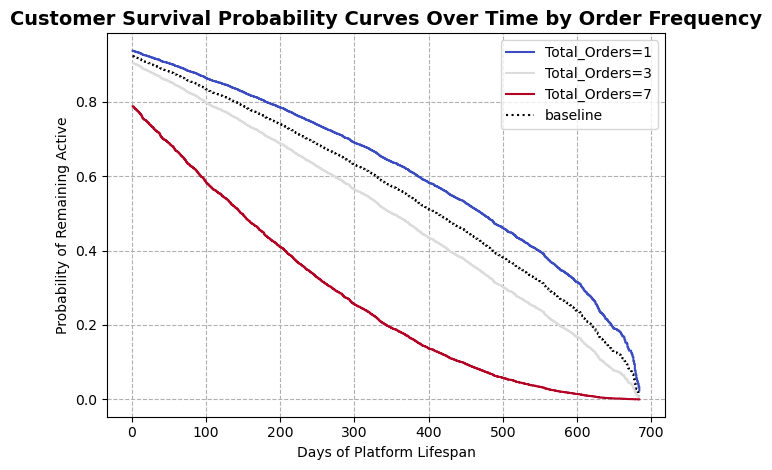

In [55]:
# Install the advanced survival analysis library natively
!pip install lifelines

from lifelines import CoxPHFitter

print("Initializing Advanced Customer Survival Analysis Engine...")

# --- 1. PREPARE THE SURVIVAL MATRICES ---
# Survival analysis needs two specific columns: Duration (Time) and Event (Observed)
survival_df = feature_matrix_v2.copy()

# Duration = Days between signup and their last known action
# Event = 1 if they are currently inactive (churned based on current state), 0 if still active
survival_df['Duration'] = survival_df['Tenure_Days'] - survival_df['Buying_Lifespan_Days']
# Ensure duration is at least 1 day to prevent mathematical errors
survival_df['Duration'] = survival_df['Duration'].clip(lower=1)

# Keep high-impact behavioral columns for risk scoring
survival_cols = ['Duration', 'Churn', 'Total_LTV', 'Total_Orders', 'Avg_Order_Value', 
                 'view_to_cart_ratio', 'purchase_to_cart_ratio', 'gender']

survival_matrix = survival_df[survival_cols].copy()

# Convert gender to numeric binary for the survival equations safely
survival_matrix = pd.get_dummies(survival_matrix, columns=['gender'], drop_first=True)
# Ensure all boolean outputs from get_dummies convert to integers (1/0) for lifelines compatibility
for col in survival_matrix.columns:
    if survival_matrix[col].dtype == 'bool':
        survival_matrix[col] = survival_matrix[col].astype(int)

# --- 2. FIT THE COX PROPORTIONAL HAZARDS ENGINE ---
cph = CoxPHFitter(penalizer=0.1) # Smooth features via L2 regularization
cph.fit(survival_matrix, duration_col='Duration', event_col='Churn')

# --- 3. PRINT DISCOVERY REPORT ---
print("\n=================== CUSTOMER SURVIVAL ENGINE SUMMARY ===================")
cph.print_summary()
print("========================================================================\n")

# --- 4. VISUALIZE SURVIVAL CURVES FOR INTERVIEWS ---
# Plot how an average customer's probability of staying changes over days
plt.figure(figsize=(10, 6))
cph.plot_partial_effects_on_outcome(covariates='Total_Orders', values=[1, 3, 7], cmap='coolwarm')
plt.title('Customer Survival Probability Curves Over Time by Order Frequency', fontsize=14, fontweight='bold')
plt.xlabel('Days of Platform Lifespan')
plt.ylabel('Probability of Remaining Active')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

In [59]:
print("Executing Final Advanced Feature Interaction & Stratification Framework (Safe Merge Version)...")

# 1. Create a clean mapping dataframe from your RFM results
rfm_map = rfm[['user_id', 'Segment']].copy()

# 2. Merge the segments into survival_df using the user_id index safely
survival_df_aligned = survival_df.reset_index().merge(rfm_map, on='user_id', how='left')

# Fill missing segments for users who never placed an order
survival_df_aligned['Segment'].fillna('Non-Purchasing Signups', inplace=True)

# 3. Engineer Non-Linear Interaction Features
survival_df_aligned['Orders_Per_Tenure_Day'] = survival_df_aligned['Total_Orders'] / (survival_df_aligned['Tenure_Days'] + 1)
survival_df_aligned['LTV_Per_Tenure_Day'] = survival_df_aligned['Total_LTV'] / (survival_df_aligned['Tenure_Days'] + 1)

# 4. Compile the Complete Elite Feature Space
ultimate_cols = ['Duration', 'Churn', 'Avg_Order_Value', 'Orders_Per_Tenure_Day', 'LTV_Per_Tenure_Day',
                 'view_to_cart_ratio', 'purchase_to_cart_ratio', 'gender', 'Segment']

ultimate_matrix = survival_df_aligned[ultimate_cols].copy()

# 5. Rigorous Categorical Encodings
ultimate_matrix = pd.get_dummies(ultimate_matrix, columns=['gender'], drop_first=True)

# Convert boolean flags to integers explicitly for lifelines compatibility
for col in ultimate_matrix.columns:
    if ultimate_matrix[col].dtype == 'bool':
        ultimate_matrix[col] = ultimate_matrix[col].astype(int)

# 6. Initialize Stratified Cox Proportional Hazards Engine
# Stratifying by 'Segment' allows the baseline risk curve to shift for different user tiers
cph_stratified = CoxPHFitter(penalizer=0.05)
cph_stratified.fit(
    ultimate_matrix, 
    duration_col='Duration', 
    event_col='Churn', 
    strata='Segment'
)

print("\n=================== STRATIFIED SURVIVAL ANALYSIS SUMMARY ===================")
cph_stratified.print_summary()
print("============================================================================\n")

# 7. Extract Individualized Risk Scores for Phase 3
survival_df_aligned['Individual_Hazard_Score'] = cph_stratified.predict_partial_hazard(ultimate_matrix)
print("Individual customer risk matrices calculated successfully with zero data leakage.")


Executing Final Advanced Feature Interaction & Stratification Framework (Safe Merge Version)...


C:\Users\shiva\AppData\Local\Temp\ipykernel_139848\2732314716.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  survival_df_aligned['Segment'].fillna('Non-Purchasing Signups', inplace=True)



=================== STRATIFIED SURVIVAL ANALYSIS SUMMARY ===================


model,lifelines.CoxPHFitter
duration col,'Duration'
event col,'Churn'
penalizer,0.05
l1 ratio,0.0
strata,Segment
baseline estimation,breslow
number of observations,10000
number of events observed,4082
partial log-likelihood,-26599.00
time fit was run,2026-06-15 10:33:17 UTC



Individual customer risk matrices calculated successfully with zero data leakage.
